In [2]:
#%pip install stable-baselines3[extra] pettingzoo gymnasium[mujoco] imageio imageio-ffmpeg matplotlib
%pip install sb3-contrib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ══════════════════════════════════════════════
#   CONFIGURATION — edit here and re-run
# ══════════════════════════════════════════════
CFG = {
    "total_timesteps": 100_000,   # ← change to 500_000 or 2_000_000 for serious training
    "race_duration_s": 60,        # maximum race duration in seconds
    "finish_line_x":  100.0,      # finish line position in metres
    "timestep_sim":   0.01,       # MuJoCo physics timestep
    "video_fps":      30,
    "save_dir":       "olympic_output",
    "seed":           42,
}

import os
os.makedirs(CFG["save_dir"], exist_ok=True)
print("✅ Configuration loaded")
print(f"   Training timesteps : {CFG['total_timesteps']:,}")
print(f"   Finish line        : x = {CFG['finish_line_x']} m")
print(f"   Race time limit    : {CFG['race_duration_s']} s")

✅ Configuration loaded
   Training timesteps : 100,000
   Finish line        : x = 100.0 m
   Race time limit    : 60 s


In [4]:
import os, xml.etree.ElementTree as ET
import gymnasium.envs.mujoco as mujoco_envs

BASE_PATH  = os.path.dirname(mujoco_envs.__file__)
ASSETS_DIR = os.path.join(BASE_PATH, "assets")

NAME_ATTRS = ["name","joint","geom","body","mesh","texture","material",
              "site","tendon","class","childclass","actuator",
              "target","cranksite","slidersite"]

def parse_agent(xml_path, prefix, spawn_pos):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    def prefixify(elem):
        for attr in NAME_ATTRS:
            if attr in elem.attrib and not elem.attrib[attr].startswith(prefix+"/"):
                elem.attrib[attr] = f"{prefix}/{elem.attrib[attr]}"
        for child in elem:
            prefixify(child)
    prefixify(root)

    bodies = []
    wb = root.find("worldbody")
    if wb is not None:
        for body in list(wb):
            for geom in list(body.findall(".//geom")):
                if geom.get("type") == "plane":
                    for p in body.iter():
                        if geom in list(p):
                            p.remove(geom); break
            body.attrib["pos"] = spawn_pos
            bodies.append(body)

    actuators = list(root.find("actuator") or [])

    assets = []
    for elem in list(root.find("asset") or []):
        if "file" in elem.attrib:
            fname = elem.attrib["file"]
            if not os.path.isabs(fname):
                full = os.path.join(ASSETS_DIR, fname)
                if os.path.exists(full):
                    elem.attrib["file"] = full
        assets.append(elem)

    default_wrapper = None
    def_sec = root.find("default")
    if def_sec is not None:
        default_wrapper = ET.Element("default", attrib={"class": prefix})
        for child in list(def_sec):
            default_wrapper.append(child)

    contacts   = list(root.find("contact")  or [])
    equalities = list(root.find("equality") or [])
    tendons    = list(root.find("tendon")   or [])

    return bodies, actuators, assets, default_wrapper, contacts, equalities, tendons


agents_cfg = [
    ("ant",      os.path.join(ASSETS_DIR, "ant.xml"),          "0  4    0.75"),
    ("cheetah",  os.path.join(ASSETS_DIR, "half_cheetah.xml"), "0  0    0.5"),
    ("humanoid", os.path.join(ASSETS_DIR, "humanoid.xml"),     "0 -4    1.25"),
]
parsed = {name: parse_agent(path, name, pos) for name, path, pos in agents_cfg}

# ── Build master XML
root_elem = ET.Element("mujoco", attrib={"model": "ai_olympics"})
ET.SubElement(root_elem, "compiler", attrib={
    "angle": "degree", "inertiafromgeom": "true", "coordinate": "local"
})
ET.SubElement(root_elem, "option", attrib={
    "timestep": str(CFG["timestep_sim"]), "integrator": "RK4", "gravity": "0 0 -9.81"
})

# Offscreen framebuffer
visual_elem = ET.SubElement(root_elem, "visual")
ET.SubElement(visual_elem, "global", attrib={"offwidth": "640", "offheight": "480"})

# Assets
asset_elem = ET.SubElement(root_elem, "asset")
for name, _, __ in agents_cfg:
    for a in parsed[name][2]: asset_elem.append(a)

# Defaults — each agent in its own class to avoid collisions
default_root = ET.SubElement(root_elem, "default")
for name, _, __ in agents_cfg:
    w = parsed[name][3]
    if w is not None: default_root.append(w)

# Worldbody
wb_elem = ET.SubElement(root_elem, "worldbody")

# Main light
ET.SubElement(wb_elem, "light", attrib={
    "directional": "true", "diffuse": ".8 .8 .8",
    "specular": ".2 .2 .2", "pos": "50 0 10", "dir": "0 0 -1"
})

# Main floor
ET.SubElement(wb_elem, "geom", attrib={
    "name": "main_floor", "type": "plane",
    "pos": "50 0 0", "size": "60 12 0.1",
    "rgba": "0.15 0.25 0.35 1", "condim": "3"
})

# Lane marker lines
for y, rgba in [("4", "1 0.85 0 0.5"), ("0", "0 0.85 1 0.5"), ("-4", "1 0.4 0.4 0.5")]:
    ET.SubElement(wb_elem, "geom", attrib={
        "type": "box", "pos": f"50 {y} 0.015",
        "size": "55 0.05 0.005", "rgba": rgba,
        "contype": "0", "conaffinity": "0"
    })

# Finish line
ET.SubElement(wb_elem, "geom", attrib={
    "type": "box", "pos": f"{CFG['finish_line_x']} 0 1",
    "size": "0.1 12 1", "rgba": "1 1 0 0.3",
    "contype": "0", "conaffinity": "0"
})

# Tracking camera — follows the centre of mass of the scene
ET.SubElement(wb_elem, "camera", attrib={
    "name":   "track",
    "pos":    "0 -20 8",
    "xyaxes": "1 0 0 0 1 3",
    "mode":   "trackcom",
})

# Agent bodies
for name, _, __ in agents_cfg:
    for body in parsed[name][0]: wb_elem.append(body)

# Contacts, equalities, tendons
for tag, idx in [("contact", 4), ("equality", 5), ("tendon", 6)]:
    sec = ET.SubElement(root_elem, tag)
    for name, _, __ in agents_cfg:
        for e in parsed[name][idx]: sec.append(e)

# Actuators
act_elem = ET.SubElement(root_elem, "actuator")
for name, _, __ in agents_cfg:
    for a in parsed[name][1]: act_elem.append(a)

# ── Save
tree = ET.ElementTree(root_elem)
ET.indent(tree, space="  ")
tree.write("arena.xml", encoding="unicode", xml_declaration=False)

import mujoco
try:
    m = mujoco.MjModel.from_xml_path("arena.xml")
    print(f"✅ arena.xml OK — nq={m.nq}  nv={m.nv}  nu={m.nu}  nbody={m.nbody}")
except Exception as e:
    print(f"❌ {e}")

✅ arena.xml OK — nq=48  nv=46  nu=31  nbody=34


C:\Users\Carla\AppData\Local\Temp\ipykernel_33256\3850568478.py:35: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  actuators = list(root.find("actuator") or [])
C:\Users\Carla\AppData\Local\Temp\ipykernel_33256\3850568478.py:38: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  for elem in list(root.find("asset") or []):
C:\Users\Carla\AppData\Local\Temp\ipykernel_33256\3850568478.py:56: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  tendons    = list(root.find("tendon")   or [])


In [5]:
import numpy as np
import gymnasium as gym
import mujoco

class SingleAgentRaceEnv(gym.Env):
    """
    gym.Env wrapper to train a single agent in its own MuJoCo model
    (standard Gymnasium ant / half_cheetah / humanoid environments).
    Reward = forward progress in X minus a small control penalty.
    """
    metadata = {"render_modes": ["rgb_array"]}

    # Only these agents support the terminate_when_unhealthy parameter
    _HEALTHY_AGENTS = {"ant", "humanoid"}

    _ENV_IDS = {
        "ant":      "Ant-v5",
        "cheetah":  "HalfCheetah-v5",
        "humanoid": "Humanoid-v5",
    }

    def __init__(self, agent_name: str, finish_x: float = 100.0,
                 max_steps: int = 2000, render_mode=None):
        super().__init__()
        self.agent_name  = agent_name
        self.finish_x    = finish_x
        self.max_steps   = max_steps
        self._step_count = 0
        self.render_mode = render_mode

        # Only pass terminate_when_unhealthy to agents that support it
        extra_kwargs = {}
        if agent_name in self._HEALTHY_AGENTS:
            extra_kwargs["terminate_when_unhealthy"] = True

        # Use the official Gymnasium environment (independent physics)
        self._env = gym.make(
            self._ENV_IDS[agent_name],
            render_mode=render_mode,
            **extra_kwargs,
        )
        self.observation_space = self._env.observation_space
        self.action_space      = self._env.action_space

    def reset(self, seed=None, options=None):
        self._step_count = 0
        obs, info = self._env.reset(seed=seed)
        self._prev_x = self._get_x()
        return obs, info

    def _get_x(self):
        return float(self._env.unwrapped.data.qpos[0])

    def step(self, action):
        obs, base_reward, terminated, truncated, info = self._env.step(action)
        self._step_count += 1

        x_now = self._get_x()
        # Reward: scaled forward progress + finish-line bonus
        dx     = x_now - self._prev_x
        reward = dx * 10.0
        self._prev_x = x_now

        if x_now >= self.finish_x:
            reward    += 500.0      # finish-line bonus
            terminated = True

        if self._step_count >= self.max_steps:
            truncated = True

        info["x_position"] = x_now
        return obs, reward, terminated, truncated, info

    def render(self):
        return self._env.render()

    def close(self):
        self._env.close()

print("✅ SingleAgentRaceEnv defined")

✅ SingleAgentRaceEnv defined


In [6]:
from stable_baselines3 import PPO, DQN
from sb3_contrib import TQC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import SubprocVecEnv, VecMonitor
import matplotlib.pyplot as plt
import numpy as np, os, time

N_ENVS = 16  # 16 parallel envs for PPO agents (ant & cheetah)

print(f"CPUs available : {os.cpu_count()}")
print(f"Parallel envs  : {N_ENVS}")

class RaceMetricsCallback(BaseCallback):
    """Records per-episode reward and final X position for plotting."""
    def __init__(self, agent_name):
        super().__init__()
        self.agent_name = agent_name
        self.ep_rewards = []
        self.ep_x_final = []

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.ep_rewards.append(info["episode"]["r"])
            if "x_position" in info:
                self.ep_x_final.append(info["x_position"])
        return True


def make_env(agent_name, finish_x, rank, seed=0):
    """Factory function to create a single environment instance."""
    def _init():
        env = SingleAgentRaceEnv(agent_name, finish_x=finish_x)
        env = Monitor(env)
        env.reset(seed=seed + rank)
        return env
    return _init


def train_agent(agent_name, total_timesteps, save_dir, seed=42):
    print(f"\n{'─'*50}")
    print(f"  Training {agent_name.upper()} · {total_timesteps:,} steps")
    print(f"{'─'*50}")

    if agent_name == "ant":
        # PPO with parallel envs
        env = SubprocVecEnv([
            make_env(agent_name, CFG["finish_line_x"], rank=i, seed=seed)
            for i in range(N_ENVS)
        ])
        env = VecMonitor(env)
        cb  = RaceMetricsCallback(agent_name)
        model = PPO("MlpPolicy", env, verbose=0, seed=seed,
                    device="cuda" if __import__("torch").cuda.is_available() else "cpu",
                    learning_rate=3e-4, n_steps=2048, batch_size=256,
                    n_epochs=10, gamma=0.99, gae_lambda=0.95,
                    clip_range=0.2, ent_coef=0.01)

    elif agent_name == "cheetah":
        from gymnasium.spaces import Discrete
        from gymnasium import ActionWrapper

        class DiscretizeCheetah(ActionWrapper):
            """Maps 9 discrete actions to fixed combinations of continuous actuators."""
            ACTIONS = [
                np.zeros(6),
                np.array([ 1, 0, 0, 0, 0, 0], dtype=np.float32),
                np.array([-1, 0, 0, 0, 0, 0], dtype=np.float32),
                np.array([ 1, 1, 0, 0, 0, 0], dtype=np.float32),
                np.array([ 0, 0, 1, 1, 0, 0], dtype=np.float32),
                np.array([ 0, 0, 0, 0, 1, 1], dtype=np.float32),
                np.array([ 1, 0, 1, 0, 1, 0], dtype=np.float32),
                np.array([ 0, 1, 0, 1, 0, 1], dtype=np.float32),
                np.ones(6,  dtype=np.float32),
            ]
            def __init__(self, env):
                super().__init__(env)
                self.action_space = Discrete(len(self.ACTIONS))
            def action(self, act):
                return self.ACTIONS[act]

        # DQN does not support SubprocVecEnv — single env with faster settings
        base_env = Monitor(DiscretizeCheetah(
            SingleAgentRaceEnv("cheetah", finish_x=CFG["finish_line_x"])
        ))
        cb  = RaceMetricsCallback("cheetah")
        model = DQN("MlpPolicy", base_env, verbose=0, seed=seed,
                    device="cuda" if __import__("torch").cuda.is_available() else "cpu",
                    learning_rate=3e-4,
                    buffer_size=100_000,
                    learning_starts=500,
                    batch_size=128,
                    gamma=0.99,
                    exploration_fraction=0.3,
                    exploration_final_eps=0.05,
                    target_update_interval=250,
                    train_freq=4)
        env = base_env

    elif agent_name == "humanoid":
        # TQC — much more efficient than SAC for complex locomotion
        base_env = Monitor(SingleAgentRaceEnv("humanoid", finish_x=CFG["finish_line_x"]))
        cb  = RaceMetricsCallback("humanoid")
        model = TQC("MlpPolicy", base_env, verbose=0, seed=seed,
                    device="cuda" if __import__("torch").cuda.is_available() else "cpu",
                    learning_rate=3e-4,
                    buffer_size=300_000,
                    learning_starts=1000,
                    batch_size=256,
                    gamma=0.99,
                    tau=0.005,
                    use_sde=True,
                    sde_sample_freq=64,
                    top_quantiles_to_drop_per_net=2)
        env = base_env

    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, callback=cb, progress_bar=True)
    elapsed = time.time() - t0

    path = os.path.join(save_dir, f"{agent_name}_model")
    model.save(path)
    print(f"  ✅ Saved to {path}.zip  ({elapsed:.0f}s)")
    env.close()
    return model, cb


# ── Train all three agents
models, callbacks = {}, {}
for ag in ["ant", "cheetah", "humanoid"]:
    models[ag], callbacks[ag] = train_agent(
        ag, CFG["total_timesteps"], CFG["save_dir"], CFG["seed"]
    )

print("\n🎓 Training complete for all three agents.")

c:\Users\Carla\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Carla\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Carla\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framewo

CPUs available : 20
Parallel envs  : 16

──────────────────────────────────────────────────
  Training ANT · 100,000 steps
──────────────────────────────────────────────────


c:\Users\Carla\AppData\Local\Programs\Python\Python313\Lib\site-packages\stable_baselines3\common\vec_env\vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Output()

  ✅ Saved to olympic_output\ant_model.zip  (32s)


Output()


──────────────────────────────────────────────────
  Training CHEETAH · 100,000 steps
──────────────────────────────────────────────────


Output()

  ✅ Saved to olympic_output\cheetah_model.zip  (80s)

──────────────────────────────────────────────────
  Training HUMANOID · 100,000 steps
──────────────────────────────────────────────────


  ✅ Saved to olympic_output\humanoid_model.zip  (2061s)

🎓 Training complete for all three agents.


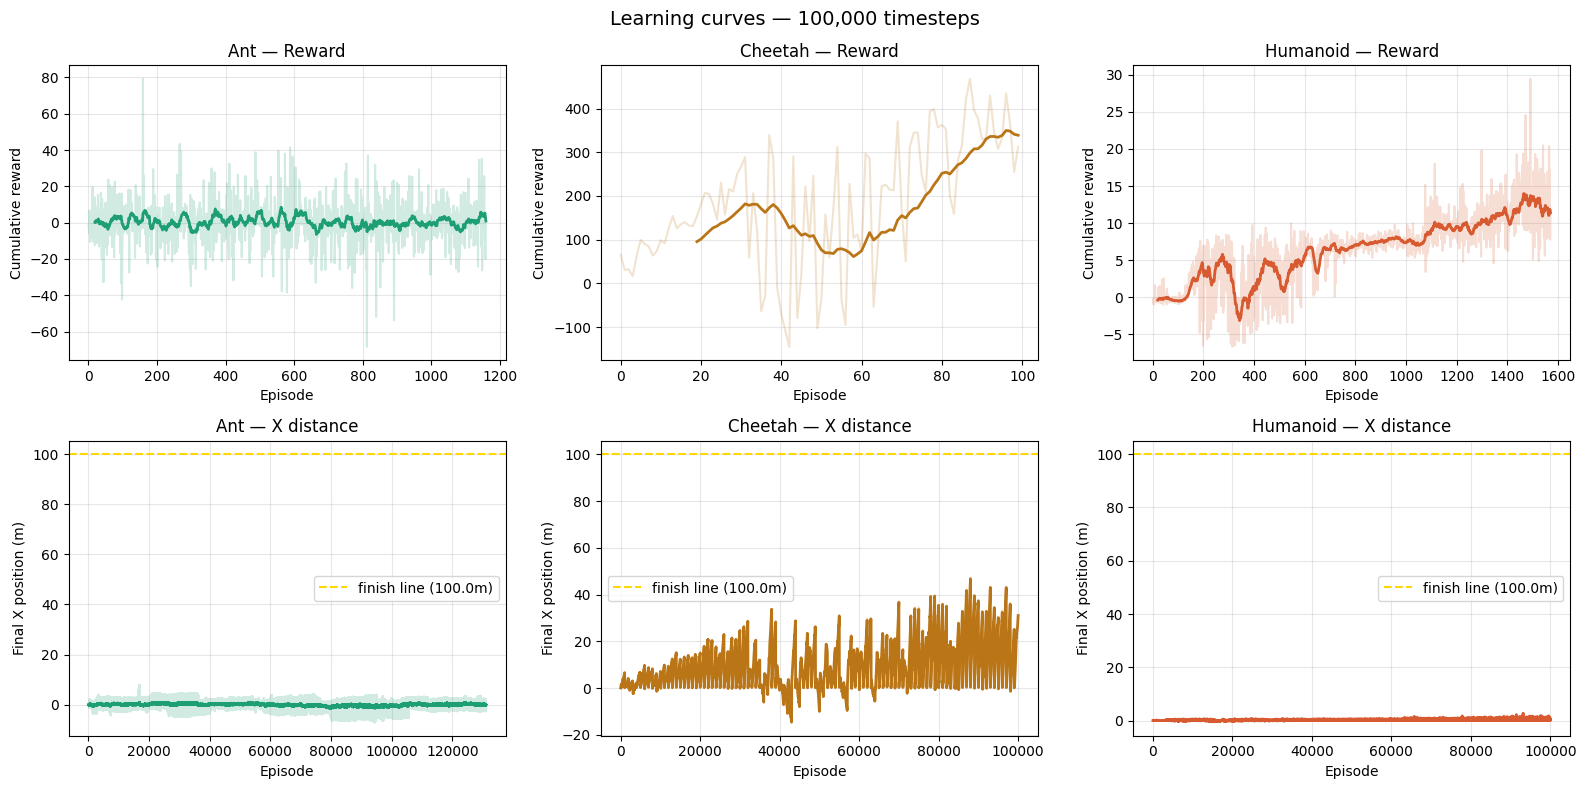

✅ Learning curves saved to olympic_output\learning_curves.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np, os

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f"Learning curves — {CFG['total_timesteps']:,} timesteps", fontsize=14)

colors = {"ant": "#1D9E75", "cheetah": "#BA7517", "humanoid": "#D85A30"}

for col, ag in enumerate(["ant", "cheetah", "humanoid"]):
    cb = callbacks[ag]
    c  = colors[ag]

    def smooth(x, w=20):
        if len(x) < w: return x
        return np.convolve(x, np.ones(w)/w, mode="valid")

    # Cumulative reward per episode
    ax = axes[0, col]
    raw = np.array(cb.ep_rewards)
    ax.plot(raw, alpha=0.2, color=c)
    if len(raw) >= 20:
        ax.plot(range(19, len(raw)), smooth(raw), color=c, linewidth=2)
    ax.set_title(f"{ag.capitalize()} — Reward")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Cumulative reward")
    ax.grid(alpha=0.3)

    # Final X position per episode
    ax2 = axes[1, col]
    xf = np.array(cb.ep_x_final)
    ax2.plot(xf, alpha=0.2, color=c)
    if len(xf) >= 20:
        ax2.plot(range(19, len(xf)), smooth(xf), color=c, linewidth=2)
    ax2.axhline(CFG["finish_line_x"], color="gold", linestyle="--",
                linewidth=1.5, label=f"finish line ({CFG['finish_line_x']}m)")
    ax2.set_title(f"{ag.capitalize()} — X distance")
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Final X position (m)")
    ax2.legend()
    ax2.grid(alpha=0.3)

plt.tight_layout()
path_plot = os.path.join(CFG["save_dir"], "learning_curves.png")
plt.savefig(path_plot, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Learning curves saved to {path_plot}")

Observation sizes: {'ant': 105, 'cheetah': 17, 'humanoid': 348}
🏁 Race started!
  t=5.0s  ant: 0.1m | cheetah: -1.6m | humanoid: -2.3m
  t=10.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -2.5m
  t=15.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -3.2m
  t=20.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -3.4m
  t=25.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -4.7m
  t=30.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -5.1m
  t=35.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -5.4m
  t=40.0s  ant: 0.2m | cheetah: -0.7m | humanoid: -4.5m
  t=45.0s  ant: 0.2m | cheetah: -0.7m | humanoid: -4.2m
  t=50.0s  ant: 0.2m | cheetah: -0.7m | humanoid: -4.2m
  t=55.0s  ant: 0.3m | cheetah: -0.7m | humanoid: -4.8m
  t=60.0s  ant: 0.3m | cheetah: -0.7m | humanoid: -5.2m
🏁 Race finished.
📹 Video saved: olympic_output\final_race.mp4

════════════════════════════════════════════════════
  🏆  FINAL RANKING
════════════════════════════════════════════════════
  1. Ant          |    0.3m |        — | ⏱ time limit
  2. Ch

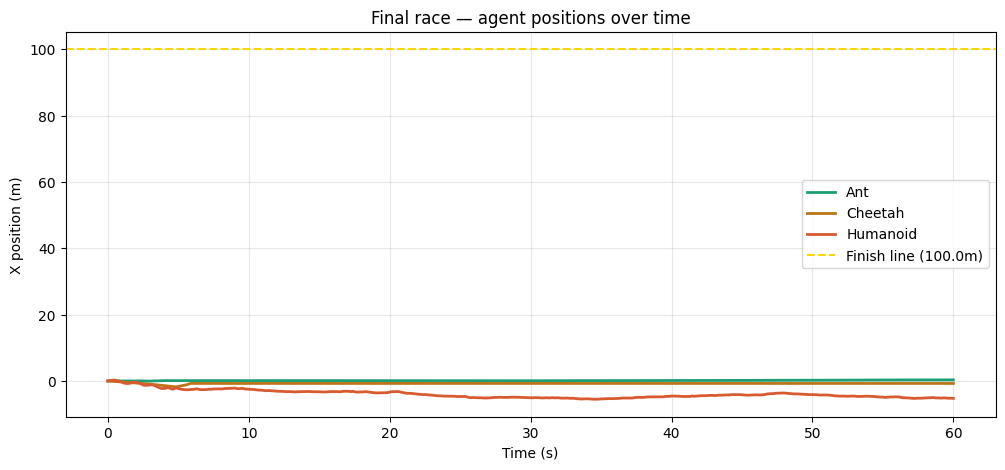

📊 Race chart saved: olympic_output\race_positions.png


In [9]:
import mujoco, time, imageio, numpy as np
from pettingzoo import ParallelEnv
import functools, gymnasium as gym, matplotlib.pyplot as plt, os

class OlympicRaceEnv(ParallelEnv):
    """Multi-agent race environment built on PettingZoo ParallelEnv."""
    metadata = {"render_modes": ["rgb_array"], "name": "olympic_race_v0"}

    def __init__(self, finish_x=100.0, race_duration_s=60.0, timestep=0.01, models_dict=None):
        self.finish_x  = finish_x
        self.max_steps = int(race_duration_s / timestep)
        self.model     = mujoco.MjModel.from_xml_path("arena.xml")
        self.data      = mujoco.MjData(self.model)
        self.renderer  = mujoco.Renderer(self.model, height=480, width=640)

        self.possible_agents = ["ant", "cheetah", "humanoid"]
        self.agents = self.possible_agents[:]

        nu = self.model.nu
        self._ctrl_slices = {
            "ant":      slice(0, 8),
            "cheetah":  slice(8, 14),
            "humanoid": slice(14, nu),
        }
        self._act_sizes = {"ant": 8, "cheetah": 6, "humanoid": nu - 14}

        # Read observation sizes directly from the trained models
        if models_dict is not None:
            self._obs_sizes = {
                ag: models_dict[ag].observation_space.shape[0]
                for ag in self.possible_agents
            }
        else:
            _tmp = {
                "ant":      gym.make("Ant-v5"),
                "cheetah":  gym.make("HalfCheetah-v5"),
                "humanoid": gym.make("Humanoid-v5"),
            }
            self._obs_sizes = {
                ag: _tmp[ag].observation_space.shape[0]
                for ag in self.possible_agents
            }
            for e in _tmp.values(): e.close()

        print(f"Observation sizes: {self._obs_sizes}")

        # qpos X index for each agent
        self._x_idx = {}
        for ag, jname in [("ant","ant/root"),("cheetah","cheetah/rootx"),("humanoid","humanoid/root")]:
            try:
                jid = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_JOINT, jname)
                self._x_idx[ag] = int(self.model.jnt_qposadr[jid])
            except:
                self._x_idx[ag] = 0

        self._step_count = 0
        self._finished   = {}
        self._finish_x_at= {}

    @functools.lru_cache(maxsize=None)
    def observation_space(self, agent):
        return gym.spaces.Box(-np.inf, np.inf, (self._obs_sizes[agent],), dtype=np.float64)

    @functools.lru_cache(maxsize=None)
    def action_space(self, agent):
        return gym.spaces.Box(-1.0, 1.0, (self._act_sizes[agent],), dtype=np.float32)

    def _get_obs(self, agent):
        size = self.observation_space(agent).shape[0]
        full = np.concatenate([self.data.qpos, self.data.qvel])
        return (full[:size] if len(full) >= size
                else np.pad(full, (0, size - len(full)))).astype(np.float64)

    def _get_x(self, agent):
        return float(self.data.qpos[self._x_idx[agent]])

    def reset(self, seed=None, options=None):
        mujoco.mj_resetData(self.model, self.data)
        self.agents      = self.possible_agents[:]
        self._step_count = 0
        self._finished   = {}
        self._finish_x_at= {}
        self._prev_x = {ag: self._get_x(ag) for ag in self.agents}
        return {ag: self._get_obs(ag) for ag in self.agents}, {}

    def step(self, actions):
        for ag, act in actions.items():
            self.data.ctrl[self._ctrl_slices[ag]] = np.clip(act, -1.0, 1.0)
        mujoco.mj_step(self.model, self.data)
        self._step_count += 1

        observations, rewards, terminations, truncations = {}, {}, {}, {}
        time_up = self._step_count >= self.max_steps

        for ag in list(self.agents):
            x = self._get_x(ag)
            observations[ag] = self._get_obs(ag)
            rewards[ag]      = float(x - self._prev_x[ag]) * 10.0
            self._prev_x[ag] = x

            finished = x >= self.finish_x
            if finished and ag not in self._finished:
                self._finished[ag]    = self._step_count
                self._finish_x_at[ag] = x
                rewards[ag] += 500.0

            terminations[ag] = finished
            truncations[ag]  = time_up and not finished

        self.agents = [ag for ag in self.agents
                       if not terminations[ag] and not truncations[ag]]

        return observations, rewards, terminations, truncations, {ag: {} for ag in observations}

    def render(self):
        # Use the tracking camera added in arena.xml
        cam_id = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_CAMERA, "track")
        self.renderer.update_scene(self.data, camera=cam_id)
        return self.renderer.render()

    def close(self):
        self.renderer.close()


def run_race_and_record(models_dict, env: OlympicRaceEnv,
                        save_dir: str, fps: int = 30):
    """Run the final race, record a video, print the ranking."""
    obs, _ = env.reset()
    frames  = []
    step    = 0
    all_x   = {ag: [0.0] for ag in env.possible_agents}

    print("🏁 Race started!")
    while env.agents:
        actions = {}
        for ag in env.agents:
            action, _ = models_dict[ag].predict(obs[ag], deterministic=True)
            actions[ag] = action

        obs, rewards, terminations, truncations, _ = env.step(actions)
        step += 1

        for ag in env.possible_agents:
            all_x[ag].append(env._get_x(ag))

        # Capture frame every 3 physics steps (~30 fps video)
        if step % 3 == 0:
            frames.append(env.render())

        if step % 500 == 0:
            pos_str = " | ".join(
                f"{ag}: {env._get_x(ag):.1f}m" for ag in env.possible_agents
            )
            print(f"  t={step * env.model.opt.timestep:.1f}s  {pos_str}")

    print("🏁 Race finished.")

    # ── Video
    video_path = os.path.join(save_dir, "final_race.mp4")
    imageio.mimwrite(video_path, frames, fps=fps, macro_block_size=None)
    print(f"📹 Video saved: {video_path}")

    # ── Ranking
    ranking = []
    for ag in env.possible_agents:
        if ag in env._finished:
            t_finish = env._finished[ag] * env.model.opt.timestep
            ranking.append((ag, t_finish, env._finish_x_at[ag], "✅ finished"))
        else:
            ranking.append((ag, None, env._get_x(ag), "⏱ time limit"))

    ranking.sort(key=lambda r: (r[1] is None, r[1] if r[1] else -r[2]))

    print("\n" + "═"*52)
    print("  🏆  FINAL RANKING")
    print("═"*52)
    rank_lines = []
    for pos, (ag, t, x, status) in enumerate(ranking, 1):
        t_str = f"{t:.2f}s" if t else "—"
        line  = f"  {pos}. {ag.capitalize():12s} | {x:6.1f}m | {t_str:>8} | {status}"
        print(line)
        rank_lines.append(line)
    print("═"*52)

    rank_path = os.path.join(save_dir, "ranking.txt")
    with open(rank_path, "w", encoding="utf-8") as f:
        f.write("FINAL RACE RANKING\n" + "═"*52 + "\n")
        for line in rank_lines:
            f.write(line + "\n")
    print(f"📄 Ranking saved: {rank_path}")

    # ── Race progress chart
    fig, ax = plt.subplots(figsize=(12, 5))
    colors  = {"ant": "#1D9E75", "cheetah": "#BA7517", "humanoid": "#D85A30"}
    for ag in env.possible_agents:
        ts = [i * env.model.opt.timestep for i in range(len(all_x[ag]))]
        ax.plot(ts, all_x[ag], label=ag.capitalize(), color=colors[ag], linewidth=2)
    ax.axhline(env.finish_x, color="gold", linestyle="--",
               linewidth=1.5, label=f"Finish line ({env.finish_x}m)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("X position (m)")
    ax.set_title("Final race — agent positions over time")
    ax.legend()
    ax.grid(alpha=0.3)
    race_plot = os.path.join(save_dir, "race_positions.png")
    plt.savefig(race_plot, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"📊 Race chart saved: {race_plot}")

    return ranking


# ── RUN
race_env = OlympicRaceEnv(
    finish_x=CFG["finish_line_x"],
    race_duration_s=CFG["race_duration_s"],
    timestep=CFG["timestep_sim"],
    models_dict=models,
)

ranking = run_race_and_record(models, race_env, CFG["save_dir"], fps=CFG["video_fps"])
race_env.close()

In [9]:
import mujoco
import numpy as np

m = mujoco.MjModel.from_xml_path("arena.xml")
d = mujoco.MjData(m)

print("=== JOINT INFO ===")
for i in range(m.njnt):
    name = mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_JOINT, i)
    print(f"  joint {i:2d}: {name:40s} qposadr={m.jnt_qposadr[i]}")

print("\n=== ACTUATOR INFO ===")
for i in range(m.nu):
    name = mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
    print(f"  actuator {i:2d}: {name}")

print(f"\n=== QPOS LAYOUT ===")
print(f"  Total qpos size: {m.nq}")
print(f"  Total ctrl size: {m.nu}")

print("\n=== X INDICES BEING USED ===")
for ag, jname in [("ant","ant/root"),("cheetah","cheetah/rootx"),("humanoid","humanoid/root")]:
    try:
        jid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, jname)
        idx = int(m.jnt_qposadr[jid])
        print(f"  {ag:10s}: joint='{jname}' -> qpos[{idx}]")
    except Exception as e:
        print(f"  {ag:10s}: joint '{jname}' not found -- {e}")

print("\n=== INITIAL QPOS (primeros 30 valores) ===")
mujoco.mj_resetData(m, d)
print(d.qpos[:30])

=== JOINT INFO ===
  joint  0: ant/root                                 qposadr=0
  joint  1: ant/hip_1                                qposadr=7
  joint  2: ant/ankle_1                              qposadr=8
  joint  3: ant/hip_2                                qposadr=9
  joint  4: ant/ankle_2                              qposadr=10
  joint  5: ant/hip_3                                qposadr=11
  joint  6: ant/ankle_3                              qposadr=12
  joint  7: ant/hip_4                                qposadr=13
  joint  8: ant/ankle_4                              qposadr=14
  joint  9: cheetah/rootx                            qposadr=15
  joint 10: cheetah/rootz                            qposadr=16
  joint 11: cheetah/rooty                            qposadr=17
  joint 12: cheetah/bthigh                           qposadr=18
  joint 13: cheetah/bshin                            qposadr=19
  joint 14: cheetah/bfoot                            qposadr=20
  joint 15: cheetah/fthig

In [10]:
from PIL import Image
import os

output_dir = "olympic_output"

# List of PNGs to convert
png_files = [
    "learning_curves.png",
    "race_positions.png",
]

for fname in png_files:
    png_path = os.path.join(output_dir, fname)
    pdf_path = os.path.join(output_dir, fname.replace(".png", ".pdf"))
    
    if os.path.exists(png_path):
        img = Image.open(png_path)
        # Convert to RGB in case it has alpha channel (RGBA)
        if img.mode in ("RGBA", "P"):
            img = img.convert("RGB")
        img.save(pdf_path, "PDF", resolution=300)
        print(f"✅ {fname} → {fname.replace('.png', '.pdf')}")
    else:
        print(f"❌ Not found: {png_path}")

✅ learning_curves.png → learning_curves.pdf
✅ race_positions.png → race_positions.pdf


In [6]:
import os

print(f"Buscando en: {os.path.abspath(CFG['save_dir'])}")
print(f"¿Existe la carpeta? {os.path.exists(CFG['save_dir'])}")
print("\nArchivos encontrados:")
if os.path.exists(CFG['save_dir']):
    for f in os.listdir(CFG['save_dir']):
        print(f"  {f}")
else:
    print("  ❌ La carpeta no existe")

Buscando en: c:\Users\Carla\Desktop\Apuntes_uni\Cuarto\Segundo Cuatri\Robótica\final work\RL-race\olympic_output
¿Existe la carpeta? True

Archivos encontrados:
  ant_model_100K.zip
  ant_model_1M.zip
  cheetah_model_100K.zip
  cheetah_model_1M.zip
  final_race_100K.mp4
  final_race_1M.mp4
  humanoid_model_100K.zip
  humanoid_model_1M.zip
  learning_curves_100K.pdf
  learning_curves_100K.png
  learning_curves_1M.pdf
  learning_curves_1M.png
  race_positions_100K.pdf
  race_positions_100K.png
  race_positions_1M.pdf
  race_positions_1M.png
  ranking_100K.txt
  ranking_1M.txt


In [7]:
from stable_baselines3 import PPO, DQN
from sb3_contrib import TQC

models = {
    "ant":      PPO.load(f"{CFG['save_dir']}/ant_model_1M"),
    "cheetah":  DQN.load(f"{CFG['save_dir']}/cheetah_model_1M"),
    "humanoid": TQC.load(f"{CFG['save_dir']}/humanoid_model_1M"),
}

print("✅ Models loaded successfully")
print(f"   Ant      obs space : {models['ant'].observation_space.shape}")
print(f"   Cheetah  obs space : {models['cheetah'].observation_space.shape}")
print(f"   Humanoid obs space : {models['humanoid'].observation_space.shape}")

✅ Models loaded successfully
   Ant      obs space : (105,)
   Cheetah  obs space : (17,)
   Humanoid obs space : (348,)


In [10]:
import imageio
# ── RUN
race_env = OlympicRaceEnv(
    finish_x=CFG["finish_line_x"],
    race_duration_s=CFG["race_duration_s"],
    timestep=CFG["timestep_sim"],
    models_dict=models,
)

obs, _ = race_env.reset()
frames  = []
step    = 0
all_x   = {ag: [0.0] for ag in race_env.possible_agents}

print("🏁 Race started!")
while race_env.agents:
    actions = {}
    for ag in race_env.agents:
        action, _ = models[ag].predict(obs[ag], deterministic=True)
        actions[ag] = action

    obs, rewards, terminations, truncations, _ = race_env.step(actions)
    step += 1

    for ag in race_env.possible_agents:
        all_x[ag].append(race_env._get_x(ag))

    # Capture every step for maximum smoothness
    frames.append(race_env.render())

    if step % 500 == 0:
        pos_str = " | ".join(
            f"{ag}: {race_env._get_x(ag):.1f}m" for ag in race_env.possible_agents
        )
        print(f"  t={step * race_env.model.opt.timestep:.1f}s  {pos_str}")

print("🏁 Race finished.")

# ── Video only
video_path = os.path.join(CFG["save_dir"], "final_race_new.mp4")
imageio.mimwrite(video_path, frames, fps=CFG["video_fps"], macro_block_size=None)
print(f"📹 Video saved: {video_path}")

race_env.close()

Observation sizes: {'ant': 105, 'cheetah': 17, 'humanoid': 348}
🏁 Race started!
  t=5.0s  ant: 0.1m | cheetah: -1.6m | humanoid: -2.3m
  t=10.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -2.5m
  t=15.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -3.2m
  t=20.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -3.4m
  t=25.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -4.7m
  t=30.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -5.1m
  t=35.0s  ant: 0.1m | cheetah: -0.7m | humanoid: -5.4m
  t=40.0s  ant: 0.2m | cheetah: -0.7m | humanoid: -4.5m
  t=45.0s  ant: 0.2m | cheetah: -0.7m | humanoid: -4.2m
  t=50.0s  ant: 0.2m | cheetah: -0.7m | humanoid: -4.2m
  t=55.0s  ant: 0.3m | cheetah: -0.7m | humanoid: -4.8m
  t=60.0s  ant: 0.3m | cheetah: -0.7m | humanoid: -5.2m
🏁 Race finished.
📹 Video saved: olympic_output\final_race_new.mp4


In [15]:
import os
import imageio
import numpy as np
from stable_baselines3 import PPO, DQN
try:
    from sb3_contrib import TQC
except ImportError:
    print("Instalando TQC...")
    !pip install sb3_contrib
    from sb3_contrib import TQC

# --- CONFIGURACIÓN DE RUTAS ---
base_path = "olympic_output"
experiment_tags = ["100K", "1M"]

def run_fixed_race(tag):
    print(f"\n🎬 GENERANDO VIDEO SEPARADO: {tag}")
    
    # 1. Diccionario de cargadores específicos por algoritmo
    loaders = {
        "ant": {"class": PPO, "file": f"ant_model_{tag}.zip"},
        "cheetah": {"class": DQN, "file": f"cheetah_model_{tag}.zip"},
        "humanoid": {"class": TQC, "file": f"humanoid_model_{tag}.zip"}
    }

    models = {}
    for name, info in loaders.items():
        path = os.path.join(base_path, info["file"])
        if os.path.exists(path):
            # Cargamos con parámetros extra para evitar bloqueos
            models[name] = info["class"].load(path, device="cpu")
            print(f"  ✅ {name} cargado ({info['class'].__name__})")
        else:
            print(f"  ⚠️ No se encontró {path}")

    # 2. Re-instanciar el entorno
    # IMPORTANTE: Revisa si en tu entrenamiento usaste algún wrapper de observación.
    # Si lo hiciste, el modelo no entenderá las observaciones de 'race_env' tal cual.
    race_env = OlympicRaceEnv(
        finish_x=CFG["finish_line_x"],
        race_duration_s=CFG["race_duration_s"],
        timestep=CFG.get("timestep_sim", 0.002),
        models_dict=models,
    )

    obs, _ = race_env.reset()
    frames = []
    step = 0
    
    print(f"  🏃 Corriendo simulación de {tag}...")
    
    while race_env.agents:
        actions = {}
        for ag in race_env.agents:
            # USAR DETERMINISTIC=TRUE ES VITAL
            # Si el agente no se mueve, probaremos a imprimir la acción para debug
            action, _ = models[ag].predict(obs[ag], deterministic=True)
            actions[ag] = action

        obs, rewards, terminations, truncations, _ = race_env.step(actions)
        frames.append(race_env.render())
        step += 1

        if step % 1000 == 0:
            # Debug: ver si las posiciones cambian
            pos_info = " | ".join([f"{a}: {race_env._get_x(a):.2f}m" for a in race_env.agents])
            print(f"    t={step*0.002:.1f}s -> {pos_info}")

    # 3. Guardar video individual
    video_name = f"final_race_{tag}_STANDALONE.mp4"
    out_path = os.path.join(base_path, video_name)
    imageio.mimwrite(out_path, frames, fps=30, macro_block_size=None)
    print(f"  🏁 VIDEO GUARDADO: {out_path}")
    race_env.close()

# --- EJECUTAR AMBOS POR SEPARADO ---
for t in experiment_tags:
    run_fixed_race(t)


🎬 GENERANDO VIDEO SEPARADO: 100K
  ✅ ant cargado (PPO)
  ✅ cheetah cargado (DQN)
  ✅ humanoid cargado (TQC)
Observation sizes: {'ant': 105, 'cheetah': 17, 'humanoid': 348}
  🏃 Corriendo simulación de 100K...
    t=2.0s -> ant: 0.11m | cheetah: -0.67m | humanoid: -5.20m
    t=4.0s -> ant: -0.00m | cheetah: 0.00m | humanoid: 0.02m
    t=6.0s -> ant: 0.00m | cheetah: -0.00m | humanoid: 0.03m
    t=8.0s -> ant: 0.00m | cheetah: -0.00m | humanoid: 0.04m
    t=10.0s -> ant: 0.00m | cheetah: -0.01m | humanoid: 0.05m
    t=12.0s -> 
  🏁 VIDEO GUARDADO: olympic_output\final_race_100K_STANDALONE.mp4

🎬 GENERANDO VIDEO SEPARADO: 1M
  ✅ ant cargado (PPO)
  ✅ cheetah cargado (DQN)
  ✅ humanoid cargado (TQC)
Observation sizes: {'ant': 105, 'cheetah': 17, 'humanoid': 348}
  🏃 Corriendo simulación de 1M...
    t=2.0s -> ant: 0.12m | cheetah: -0.73m | humanoid: -2.48m
    t=4.0s -> ant: 0.08m | cheetah: -0.73m | humanoid: -3.35m
    t=6.0s -> ant: 0.09m | cheetah: -0.73m | humanoid: -5.05m
    t=8.0s 